<a href="https://colab.research.google.com/github/sevaradevoloper/mldanishla/blob/main/SpotifyTracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install legacy-cgi

In [54]:
# 🎹 Spotify Tracks Dataset

In [55]:
import opendatasets as od

In [56]:
od.download("https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset")

Skipping, found downloaded files in "./-spotify-tracks-dataset" (use force=True to force download)


In [57]:
!kaggle datasets download -d maharshipandya/spotify-tracks-dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("/content/-spotify-tracks-dataset/dataset.csv")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [60]:
df.shape

(114000, 21)

In [61]:
print(df.isnull().sum())
print(df.duplicated().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
0


In [62]:
df.columns.tolist()

['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [63]:
# Preprocessing:

In [66]:
drop_cols = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
df_clean = df.drop(columns=drop_cols)
df["track_genre"] = df["track_genre"].astype("category")
df_clean.info()
df["track_genre"].dtype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   popularity        114000 non-null  int64   
 1   duration_ms       114000 non-null  int64   
 2   explicit          114000 non-null  bool    
 3   danceability      114000 non-null  float64 
 4   energy            114000 non-null  float64 
 5   key               114000 non-null  int64   
 6   loudness          114000 non-null  float64 
 7   mode              114000 non-null  int64   
 8   speechiness       114000 non-null  float64 
 9   acousticness      114000 non-null  float64 
 10  instrumentalness  114000 non-null  float64 
 11  liveness          114000 non-null  float64 
 12  valence           114000 non-null  float64 
 13  tempo             114000 non-null  float64 
 14  time_signature    114000 non-null  int64   
 15  track_genre       114000 non-null  category
dtypes:

CategoricalDtype(categories=['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
                  'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
                  ...
                  'spanish', 'study', 'swedish', 'synth-pop', 'tango',
                  'techno', 'trance', 'trip-hop', 'turkish', 'world-music'],
, ordered=False, categories_dtype=object)

In [64]:
# y ustunimiz bu Popularity uni korib olamiz

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


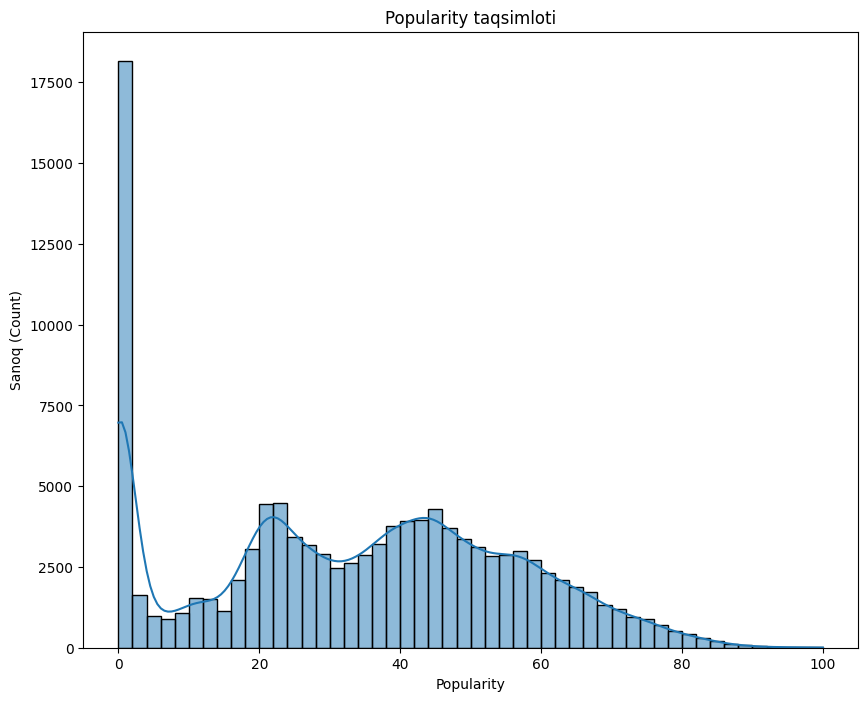

In [70]:
print(df_clean["popularity"].describe())

plt.figure(figsize=(10,8))
sns.histplot(data=df_clean['popularity'],bins=50,kde=True)
plt.title("Popularity taqsimloti")
plt.xlabel('Popularity')
plt.ylabel('Sanoq (Count)')
plt.show()